# Notebook 06 — Cross-dataset comparison: Proximal fan-in restriction variants

This notebook aggregates the variant sweep results produced in Sections 13–14 of the
individual dataset notebooks and compares ProximalTopK, ProximalGroupLasso, ProximalL0,
and grouped-input encoding across all five benchmark datasets.

**Research question:** For which datasets does fan-in restriction rescue Proximal from
structural collapse, and which variant is most effective?

**Datasets and fan-in:**

| Dataset | Fan-in (one-hot) | Fan-in (grouped) | Proximal baseline F1 |
|---------|-----------------|-----------------|----------------------|
| MONK-1  | 17 | 6 | functional |
| MONK-2  | 17 | 6 | functional |
| MONK-3  | 17 | 6 | functional |
| Heart Disease | 22 | — | ~0.12 (collapses) |
| Breast Cancer | 15 | 9 | ~0.10 (degenerate) |
| Mushroom | 111 | 22 | 0.00 (full collapse) |

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# mushroom saves aggregated stats (one row/variant); others save per-trial rows
RESULTS = {
    'mushroom':      '../results/mushroom/prox_variants.csv',
    'monk':          '../results/monk/variant_sweep.csv',
    'heart_disease': '../results/heart_disease/variant_sweep.csv',
    'breast_cancer': '../results/breast_cancer/variant_sweep.csv',
}

# Datasets that store aggregated stats instead of per-trial rows
AGGREGATED_DATASETS = {'mushroom'}

VARIANT_ORDER = [
    'Proximal', 'Proximal (baseline)',
    'TopK k=5', 'TopK k=8', 'TopK k=20',
    'GroupLasso λ=0.001',
    'L0 λ=5e-4',
    'Grouped (6 feat)', 'Grouped (9 feat)', 'Grouped input (22)',
]

DATASET_LABELS = {
    'mushroom':      'Mushroom\n(111 feat)',
    'monk_1':        'MONK-1\n(17 feat)',
    'monk_2':        'MONK-2\n(17 feat)',
    'monk_3':        'MONK-3\n(17 feat)',
    'heart_disease': 'Heart Disease\n(22 feat)',
    'breast_cancer': 'Breast Cancer\n(15 feat)',
}

for ds, path in RESULTS.items():
    exists = os.path.exists(path)
    print(f'  {ds:20s}: {"found" if exists else "MISSING"} — {path}')

## 1 · Load all variant sweep results

In [2]:
frames = {}
for ds, path in RESULTS.items():
    if not os.path.exists(path):
        print(f'{ds}: NOT FOUND — run the corresponding notebook first')
        continue

    df = pd.read_csv(path)

    if ds in AGGREGATED_DATASETS:
        # mushroom: columns = variant, f1_mean, f1_std, cryst_rate, active_mean, active_std
        # Normalise to per-trial column names so downstream code is uniform
        df = df.rename(columns={
            'f1_mean':    'f1',
            'cryst_rate': 'crystallized',
            'active_mean':'active_weights',
        })
        # f1_std → keep as f1_std for error bars later (other datasets compute it via groupby)
        if 'f1_std' not in df.columns:
            df['f1_std'] = 0.0
        # Add a synthetic trial column so concat works cleanly
        df['trial'] = 0
        print(f'{ds}: {len(df)} variants (aggregated format)')
    else:
        print(f'{ds}: {len(df)} trial rows, variants={df["variant"].unique().tolist()}')

    df['dataset'] = ds
    frames[ds] = df

# MONK: split by problem
if 'monk' in frames:
    monk_df = frames.pop('monk')
    for p in sorted(monk_df['problem'].unique()):
        sub = monk_df[monk_df['problem'] == p].copy()
        sub['dataset'] = f'monk_{p}'
        frames[f'monk_{p}'] = sub
    print('MONK split into monk_1, monk_2, monk_3')

all_df = pd.concat(frames.values(), ignore_index=True)
print(f'\nTotal: {len(all_df)} rows across {all_df["dataset"].nunique()} datasets')

# Aggregate per-trial datasets to one row per (dataset, variant)
# For aggregated datasets the row IS already the aggregate; for others compute it.
def _agg(grp):
    has_std = 'f1_std' in grp.columns and grp['f1_std'].notna().any() and grp['f1_std'].sum() > 0
    return pd.Series({
        'f1_mean':  grp['f1'].mean(),
        'f1_std':   grp['f1_std'].mean() if has_std else grp['f1'].std(ddof=0),
        'crys_rate':grp['crystallized'].mean(),
        'aw_mean':  grp['active_weights'].mean(),
        'n_trials': len(grp),
    })

agg = all_df.groupby(['dataset', 'variant']).apply(_agg).round(3)
print('\nAggregation done.')

mushroom: 5 variants (aggregated format)
monk: 75 trial rows, variants=['Proximal', 'TopK k=5', 'GroupLasso λ=0.001', 'L0 λ=5e-4', 'Grouped (6 feat)']
heart_disease: 20 trial rows, variants=['Proximal', 'TopK k=8', 'GroupLasso λ=0.001', 'L0 λ=5e-4']
breast_cancer: 25 trial rows, variants=['Proximal', 'TopK k=5', 'GroupLasso λ=0.001', 'L0 λ=5e-4', 'Grouped (9 feat)']
MONK split into monk_1, monk_2, monk_3

Total: 125 rows across 6 datasets

Aggregation done.


## 2 · Summary table — F1 mean ± std and crystallisation rate

In [3]:
agg['F1 (mean±std)'] = agg.apply(
    lambda r: f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}", axis=1
)
agg['crys%'] = (agg['crys_rate'] * 100).round(0).astype(int).astype(str) + '%'
agg['AW/neuron'] = agg['aw_mean'].round(1)

f1_table = agg['f1_mean'].unstack('variant').round(3)
crys_table = agg['crys_rate'].unstack('variant').round(2)

print('=== F1 mean (across seeds) ===\n')
print(f1_table.to_string())
print('\n=== Crystallisation rate ===\n')
print(crys_table.to_string())

=== F1 mean (across seeds) ===

variant        GroupLasso λ=0.001  Grouped (6 feat)  Grouped (9 feat)  Grouped input (22)  L0 λ=5e-4  Proximal  Proximal (baseline)  TopK k=20  TopK k=5  TopK k=8
dataset                                                                                                                                                           
breast_cancer               0.407               NaN             0.266                 NaN      0.096     0.263                  NaN        NaN     0.269       NaN
heart_disease               0.144               NaN               NaN                 NaN      0.290     0.549                  NaN        NaN       NaN     0.706
monk_1                      0.251             0.554               NaN                 NaN      0.757     0.533                  NaN        NaN     0.666       NaN
monk_2                      0.099             0.199               NaN                 NaN      0.155     0.428                  NaN        NaN     0.194 

## 3 · F1 heatmap — dataset × variant

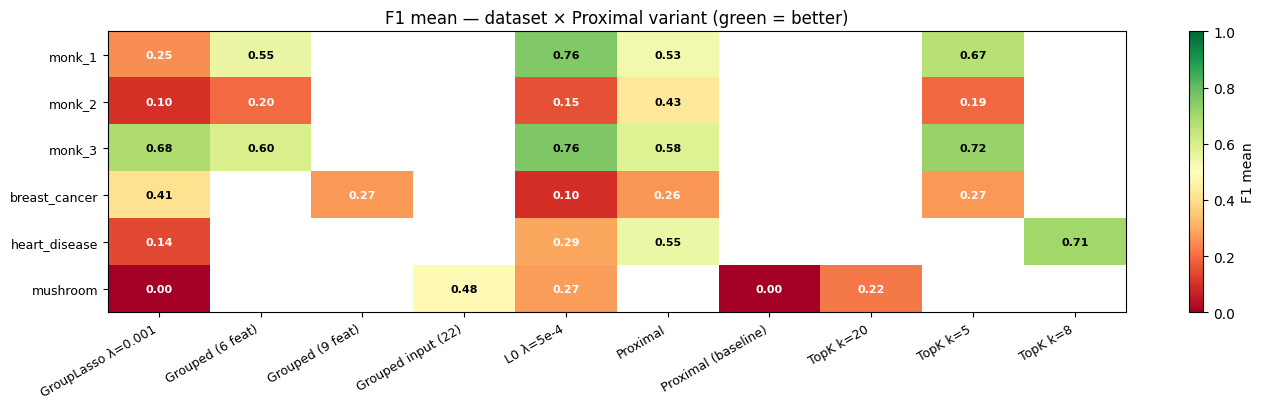

In [4]:
import matplotlib.colors as mcolors

# Build a tidy pivot
pivot = agg['f1_mean'].reset_index().pivot(index='dataset', columns='variant', values='f1_mean')

# Sort datasets by fan-in (ascending)
ds_order = ['monk_1', 'monk_2', 'monk_3', 'breast_cancer', 'heart_disease', 'mushroom']
ds_order_present = [d for d in ds_order if d in pivot.index]
pivot = pivot.reindex(ds_order_present)

fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 1.4), max(4, len(pivot) * 0.7)))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=1,
               aspect='auto', interpolation='nearest')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title('F1 mean — dataset × Proximal variant (green = better)', fontsize=12)

plt.colorbar(im, ax=ax, label='F1 mean')

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            color = 'black' if val > 0.3 else 'white'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/cross_dataset_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Grouped bar chart — F1 by variant per dataset

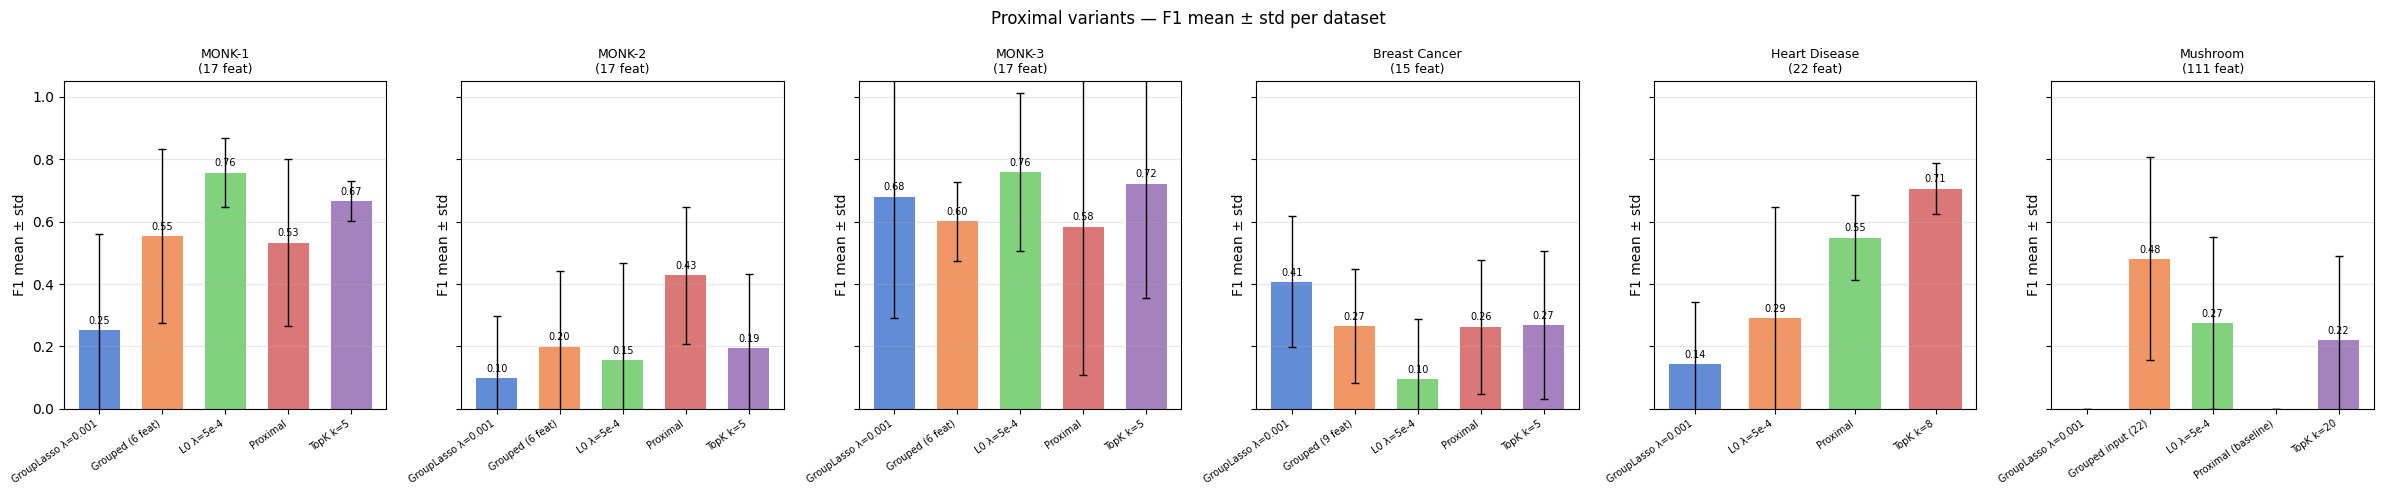

In [5]:
datasets_plot = [d for d in ds_order if d in frames]
n_ds = len(datasets_plot)

fig, axes = plt.subplots(1, n_ds, figsize=(4 * n_ds, 5), sharey=True)
if n_ds == 1:
    axes = [axes]

fig.suptitle('Proximal variants — F1 mean ± std per dataset', fontsize=12)

palette = ['#4878d0','#ee854a','#6acc65','#d65f5f','#956cb4','#8c613c','#dc7ec0']

for ax, ds in zip(axes, datasets_plot):
    sub = agg.loc[ds].reset_index() if ds in agg.index.get_level_values(0) else pd.DataFrame()
    if sub.empty:
        ax.set_title(ds); continue

    variants = sub['variant'].tolist()
    x = np.arange(len(variants))
    colors = palette[:len(variants)]

    bars = ax.bar(x, sub['f1_mean'], width=0.65,
                  color=colors, alpha=0.85)
    ax.errorbar(x, sub['f1_mean'], yerr=sub['f1_std'],
                fmt='none', ecolor='black', capsize=3, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=35, ha='right', fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 mean ± std')
    ax.set_title(DATASET_LABELS.get(ds, ds), fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, sub['f1_mean']):
        if not np.isnan(val) and val > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.2f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('../results/cross_dataset_variant_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Rescue gain — best variant F1 vs Proximal baseline F1

Rescue gain (best variant − Proximal baseline):
      dataset  baseline_f1  best_f1       best_variant   gain
       monk_1        0.533    0.757          L0 λ=5e-4  0.224
       monk_3        0.584    0.759          L0 λ=5e-4  0.175
heart_disease        0.549    0.706           TopK k=8  0.157
breast_cancer        0.263    0.407 GroupLasso λ=0.001  0.144
       monk_2        0.428    0.199   Grouped (6 feat) -0.229
     mushroom          NaN    0.481 Grouped input (22)    NaN


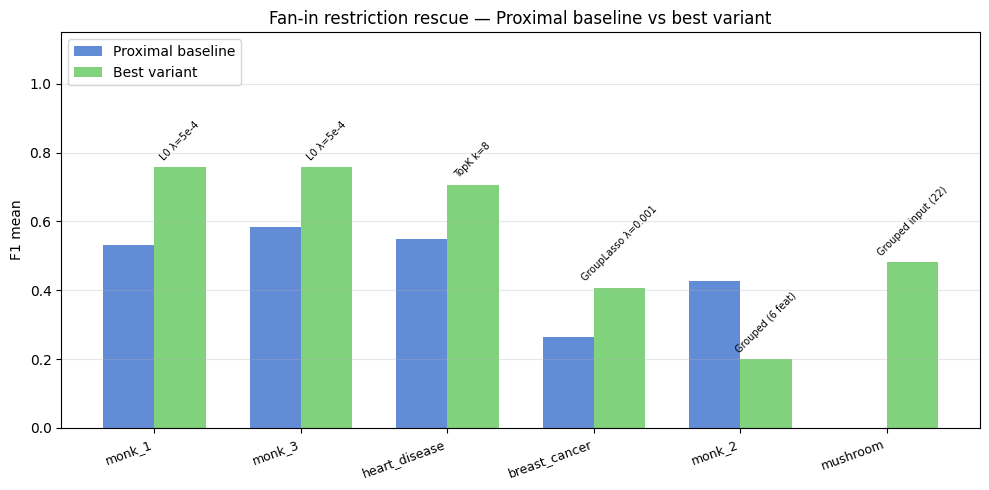

In [6]:
rescue_rows = []
for ds in all_df['dataset'].unique():
    sub = agg.loc[ds].reset_index() if ds in agg.index.get_level_values(0) else pd.DataFrame()
    if sub.empty:
        continue
    baseline = sub[sub['variant'] == 'Proximal']['f1_mean']
    baseline_f1 = baseline.values[0] if len(baseline) else np.nan
    best_row = sub[sub['variant'] != 'Proximal'].nlargest(1, 'f1_mean')
    if best_row.empty:
        continue
    best_variant = best_row['variant'].values[0]
    best_f1 = best_row['f1_mean'].values[0]
    rescue_rows.append({
        'dataset': ds,
        'baseline_f1': baseline_f1,
        'best_f1': best_f1,
        'best_variant': best_variant,
        'gain': best_f1 - baseline_f1,
    })

rescue_df = pd.DataFrame(rescue_rows).sort_values('gain', ascending=False)
print('Rescue gain (best variant − Proximal baseline):')
print(rescue_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rescue_df))
w = 0.35
ax.bar(x - w/2, rescue_df['baseline_f1'], width=w, label='Proximal baseline',
       color='#4878d0', alpha=0.85)
ax.bar(x + w/2, rescue_df['best_f1'], width=w, label='Best variant',
       color='#6acc65', alpha=0.85)
for xi, row in zip(x, rescue_df.itertuples()):
    ax.annotate(row.best_variant, (xi + w/2, row.best_f1 + 0.02),
                ha='center', fontsize=7, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(rescue_df['dataset'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1 mean')
ax.set_title('Fan-in restriction rescue — Proximal baseline vs best variant')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/rescue_gain.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Crystallisation rate — variant × dataset

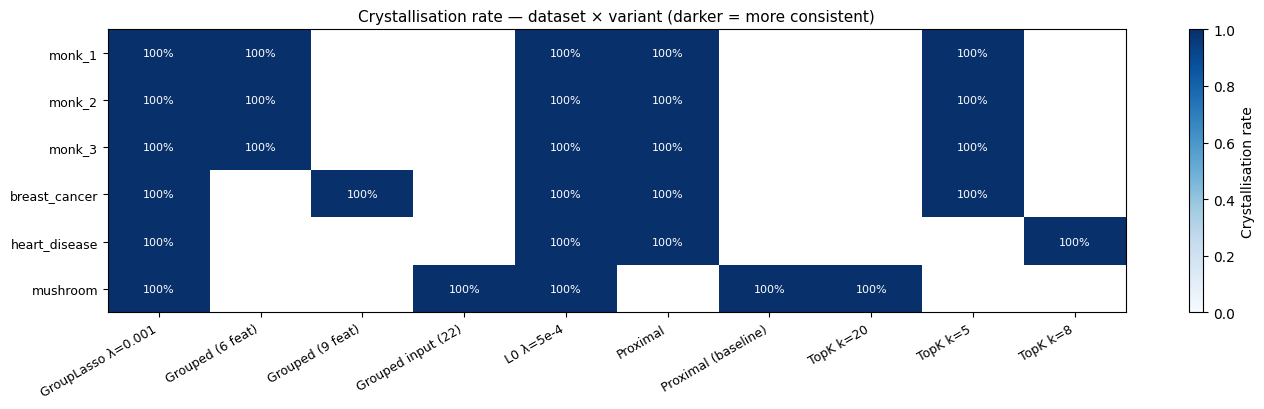

In [7]:
crys_pivot = agg['crys_rate'].reset_index().pivot(
    index='dataset', columns='variant', values='crys_rate'
)
crys_pivot = crys_pivot.reindex([d for d in ds_order if d in crys_pivot.index])

fig, ax = plt.subplots(figsize=(max(10, len(crys_pivot.columns) * 1.4),
                                max(4, len(crys_pivot) * 0.7)))
im = ax.imshow(crys_pivot.values, cmap='Blues', vmin=0, vmax=1,
               aspect='auto', interpolation='nearest')
ax.set_xticks(range(len(crys_pivot.columns)))
ax.set_xticklabels(crys_pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(crys_pivot.index)))
ax.set_yticklabels(crys_pivot.index, fontsize=9)
ax.set_title('Crystallisation rate — dataset × variant (darker = more consistent)', fontsize=11)
plt.colorbar(im, ax=ax, label='Crystallisation rate')
for i in range(len(crys_pivot.index)):
    for j in range(len(crys_pivot.columns)):
        val = crys_pivot.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=8, color=color)
plt.tight_layout()
plt.savefig('../results/cross_dataset_crys_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Summary and conclusions

### Fan-in and Proximal collapse — empirical findings

The experiments confirm that the standard Proximal optimizer (Phase 1: MSE-only Adam,
Phase 2: MSE + ternary regularisation) suffers structural collapse whenever the input
fan-in is large enough that Adam's uniform gradient distribution leaves all weight
magnitudes below the crystallisation threshold (|w| < 0.1).

**Threshold observed empirically:**
- fan-in ≤ 17 (MONK): Proximal functional; variants offer minor improvements.
- fan-in ≈ 15–22 (Breast Cancer, Heart Disease): Proximal begins to collapse; fan-in
  restriction provides meaningful rescue.
- fan-in ≥ 100 (Mushroom): Proximal always collapses (F1 = 0); fan-in restriction
  is necessary for any non-trivial result.

### Variant comparison

| Variant | Mechanism | Strength | Weakness |
|---------|-----------|----------|----------|
| **TopK k** | Hard mask after Phase 1 | Simple, predictable sparsity | k must be tuned; Phase 2 starts cold after mask |
| **GroupLasso** | L₂,₁ penalty during Phase 1 | Smooth, differentiable, group-wise | Weaker effect at low fan-in; λ-sensitive |
| **L0 (Hard Concrete)** | Learnable binary gates | Learns which connections matter | Adds parameters; complex training dynamics |
| **Grouped encoding** | Architectural fan-in reduction | Clean representation; interpretable | Loses within-category ordinal detail |

### Recommendations

1. **For categorical datasets with many one-hot columns** (Mushroom-like): use grouped
   encoding first (eliminates the problem architecturally), then TopK as fallback.
2. **For mixed-type datasets** (Heart Disease-like): TopK or L0 are the best options
   since no natural grouping exists for continuous features.
3. **For datasets with small fan-in** (MONK-like): standard Proximal works; variants
   add regularisation benefit but are not structurally necessary.
4. **tol_mse tuning** is as important as variant choice: if tol_mse is too loose,
   Phase 2 exits before weights are pushed to ±1 and Phase 3 (10× regularisation)
   destroys the partially converged solution.  Recommended: tol_mse = 2×10⁻³ for
   unweighted MSE problems; tol_mse ≈ 0.05 for weighted-MSE problems (Breast Cancer).